# 2.7 — Upper-Confidence-Bound Action Selection

---

## The complaint about $\varepsilon$-greedy

$\varepsilon$-greedy explores, but **indiscriminately**. When it decides to explore it
picks uniformly at random — giving an arm you have pulled 400 times the same
exploratory attention as one you have pulled twice, and giving an obviously terrible
arm the same attention as a close runner-up.

We would like to explore *preferentially among actions that could plausibly still be
best*. Two things make an action plausible:

- its estimate is high, or
- its estimate is **uncertain**.

## The rule

$$A_t \;\doteq\; \operatorname*{arg\,max}_a \left[\, Q_t(a) \;+\; c\,\sqrt{\frac{\ln t}{N_t(a)}}\,\right]$$

with the convention that if $N_t(a) = 0$, then $a$ is treated as maximising (so every
action is tried once first). $c > 0$ controls the degree of exploration.

## Reading the bonus term

$$\underbrace{c}_{\text{how much optimism}} \;\times\; \sqrt{\frac{\overbrace{\ln t}^{\text{grows, slowly}}}{\underbrace{N_t(a)}_{\text{shrinks it}}}}$$

- **$N_t(a)$ in the denominator:** each pull of $a$ shrinks $a$'s own bonus. Uncertainty
  about $a$ decreases as $1/\sqrt{N_t(a)}$ — the standard error of a mean. The bonus *is*
  a confidence-interval width.
- **$\ln t$ in the numerator:** every step you *don't* pull $a$, $a$'s bonus creeps up.
  Time passing is itself a reason to re-check a neglected arm.
- **$\ln$, not $t$:** the growth is unbounded (so nothing is abandoned forever) but
  vanishingly slow (so you do not waste steps re-checking clearly bad arms).

This is "**optimism in the face of uncertainty**": act as if each action is as good as
its upper confidence bound. If the optimism is justified you gain; if not, you learn —
and the bonus shrinks. Either way the step is not wasted, which is precisely why UCB
achieves $O(\log T)$ regret while fixed-$\varepsilon$ greedy is stuck at $O(T)$.

## Where the $\sqrt{\ln t / N}$ comes from

Hoeffding's inequality: for a mean of $N$ bounded samples,

$$P\Big(q_*(a) > Q_t(a) + u\Big) \;\le\; e^{-2 N_t(a) u^2}$$

Set the right side to $t^{-4}$ and solve for $u$: $u = \sqrt{2\ln t / N_t(a)}$. So the
bonus is exactly the width of a confidence interval whose failure probability shrinks
polynomially in $t$. The constant $c$ absorbs the reward scale (Hoeffding assumes bounded
rewards; Gaussian rewards need a different constant, which is why $c \approx 2$ is tuned
empirically here rather than derived).

In [1]:
import sys, os
sys.path.insert(0, os.getcwd())

import numpy as np
import matplotlib.pyplot as plt
from bandit_utils import (Testbed, run_bandit, plot_pair, argmax_random_tiebreak,
                          hide, banner, RUNS, STEPS)

plt.rcParams["figure.dpi"] = 110
banner()

mode=FULL  runs=2000  steps=1000
switch with:  import os; os.environ['RL_MODE']='FULL'  (before importing)


In [2]:
class EpsGreedy:
    def __init__(self, k, runs, rng, eps=0.1, Q_init=0.0, alpha=None):
        self.k, self.runs, self.rng, self.eps = k, runs, rng, eps
        self.alpha = alpha
        self.Q = np.full((runs, k), float(Q_init))
        self.N = np.zeros((runs, k))

    def act(self):
        greedy = argmax_random_tiebreak(self.Q, self.rng)
        rand = self.rng.integers(0, self.k, size=self.runs)
        explore = self.rng.random(self.runs) < self.eps
        return np.where(explore, rand, greedy)

    def update(self, a, r):
        idx = np.arange(self.runs)
        self.N[idx, a] += 1
        step = self.alpha if self.alpha else 1.0 / self.N[idx, a]
        self.Q[idx, a] += step * (r - self.Q[idx, a])


def eps_agent(eps, Q_init=0.0, alpha=None):
    return lambda k, runs, rng: EpsGreedy(k, runs, rng, eps=eps,
                                          Q_init=Q_init, alpha=alpha)

class UCB:
    def __init__(self, k, runs, rng, c=2.0, alpha=None):
        self.k, self.runs, self.rng, self.c, self.alpha = k, runs, rng, c, alpha
        self.Q = np.zeros((runs, k))
        self.N = np.zeros((runs, k))
        self.t = 0

    def act(self):
        self.t += 1
        with np.errstate(divide="ignore", invalid="ignore"):
            bonus = self.c * np.sqrt(np.log(self.t) / self.N)
        bonus[self.N == 0] = np.inf
        return argmax_random_tiebreak(self.Q + bonus, self.rng)

    def update(self, a, r):
        idx = np.arange(self.runs)
        self.N[idx, a] += 1
        step = self.alpha if self.alpha else 1.0 / self.N[idx, a]
        self.Q[idx, a] += step * (r - self.Q[idx, a])


def ucb_agent(c, alpha=None):
    return lambda k, runs, rng: UCB(k, runs, rng, c=c, alpha=alpha)

print("agents defined")

agents defined


---

### Predict first

We compare UCB ($c=2$) against $\varepsilon$-greedy ($\varepsilon = 0.1$)
on the standard testbed.

1. Which is ahead at step 1000?
2. What happens on the first 10 steps of UCB, and is it deterministic?
3. Recall the spike at step 11 in the optimistic-greedy plot. Will UCB have one too?
   Will it be bigger or smaller?

*Write your guess down (mentally or in the cell below) before running the next cell. The point is not to be right — it is to make the surprise informative when you are wrong.*

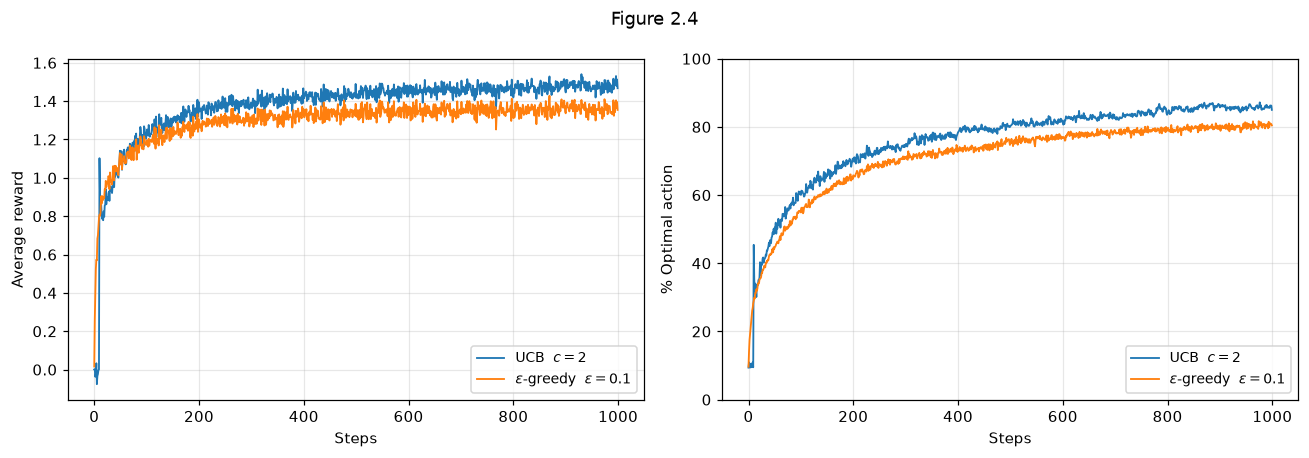

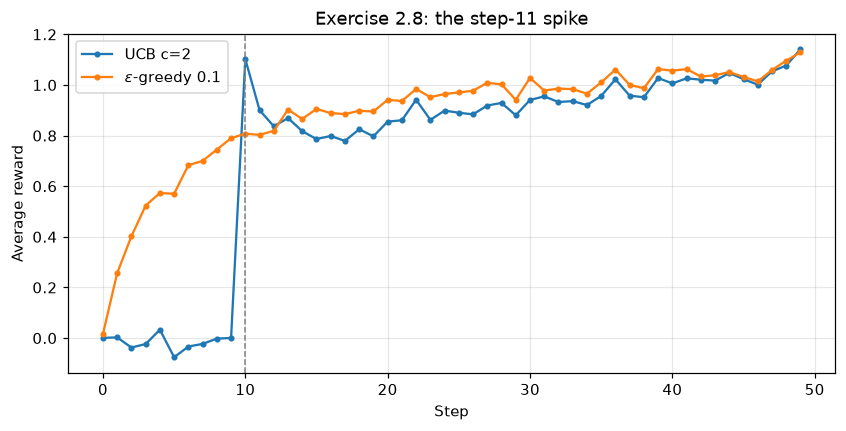

UCB reward, steps 9-14: [-0.002  0.     1.102  0.901  0.837  0.869]
final 100 steps  UCB: 1.481  eps-greedy: 1.362


In [3]:
ucb = run_bandit(ucb_agent(2.0), seed=7)
eg = run_bandit(eps_agent(0.1), seed=7)

plot_pair([ucb, eg], ["UCB  $c=2$", "$\\varepsilon$-greedy  $\\varepsilon=0.1$"],
          title="Figure 2.4")
plt.show()

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(ucb["rewards"][:50], "o-", ms=3, label="UCB c=2")
ax.plot(eg["rewards"][:50], "o-", ms=3, label="$\\varepsilon$-greedy 0.1")
ax.axvline(10, color="gray", ls="--", lw=1)
ax.set_xlabel("Step"); ax.set_ylabel("Average reward"); ax.legend(); ax.grid(alpha=0.3)
ax.set_title("Exercise 2.8: the step-11 spike")
plt.show()

print("UCB reward, steps 9-14:", np.round(ucb['rewards'][8:14], 3))
print("final 100 steps  UCB:", round(ucb['rewards'][-100:].mean(), 3),
      " eps-greedy:", round(eg['rewards'][-100:].mean(), 3))

## Exercise 2.8 — UCB Spikes

> In Figure 2.4 the UCB algorithm shows a distinct spike in performance on the 11th step.
> Why is this? Note that for your answer to be fully satisfactory it must explain both why
> the reward increases on the 11th step and why it decreases on the subsequent steps.
> Hint: if $c = 1$ the spike is less prominent.

**Steps 1–10.** Every arm has $N_t(a) = 0$, hence infinite bonus, so UCB tries each arm
exactly once in a random order. Average reward over these steps is just the mean of
$q_*$, i.e. 0. This is *forced*, identical across all runs — perfect phase alignment.

**Step 11.** Now $N_{11}(a) = 1$ for every $a$, so the bonus $c\sqrt{\ln 11 / 1}$ is
**identical for all arms**. The bonus cancels out of the argmax entirely, and UCB picks
$\arg\max_a Q_{11}(a)$ — the arm with the best single observed reward. That is a
genuinely informative choice, so average reward jumps well above 0. **Spike.**

**Step 12 onward.** The arm chosen at step 11 now has $N = 2$ while every other arm has
$N = 1$, so its bonus drops by a factor $1/\sqrt{2}$ relative to everyone else — a
penalty of $c(1 - 1/\sqrt2)\sqrt{\ln t} \approx 0.29c\sqrt{\ln t}$. For $c=2$ at $t=12$
that is about $0.98$, larger than the typical gap between arms, so UCB is pushed to a
*different* arm — usually a worse one. **Dip.** Only when $c$ is small does the value
term win and the agent stay on the good arm — hence the hint about $c=1$.

Let us confirm the $c$-dependence directly.

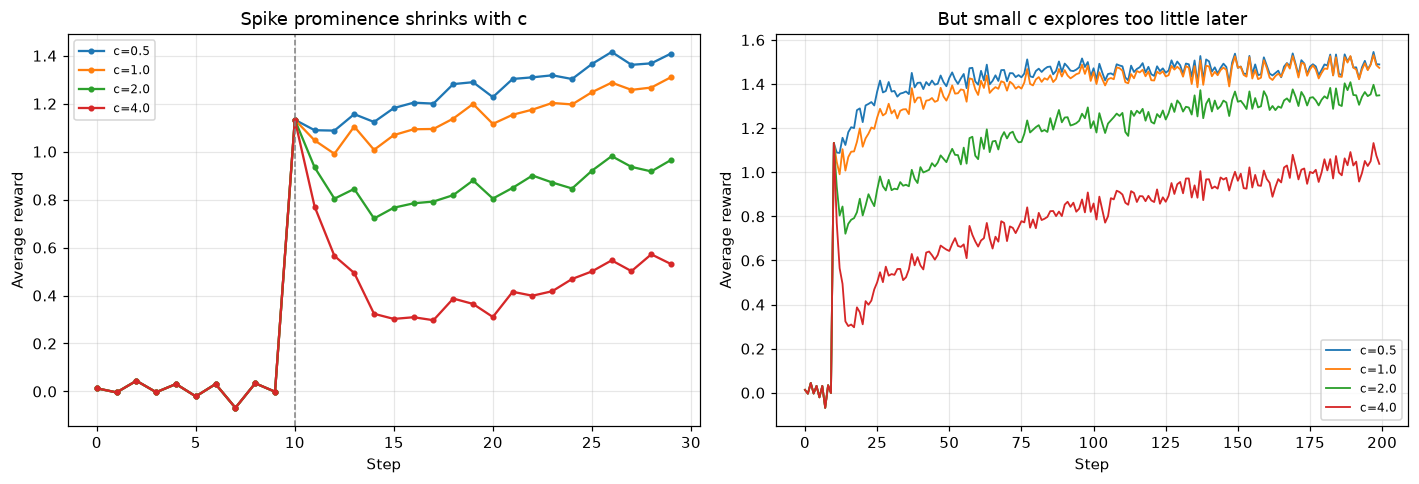

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for c in [0.5, 1.0, 2.0, 4.0]:
    r = run_bandit(ucb_agent(c), steps=200, runs=1500, seed=8)
    axes[0].plot(r["rewards"][:30], "o-", ms=3, label=f"c={c}")
    axes[1].plot(r["rewards"], lw=1.2, label=f"c={c}")
axes[0].axvline(10, color="gray", ls="--", lw=1)
axes[0].set_title("Spike prominence shrinks with c")
axes[1].set_title("But small c explores too little later")
for ax in axes:
    ax.set_xlabel("Step"); ax.set_ylabel("Average reward")
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

In [5]:
hide('''The spike is <b>largest for large c</b>, because a large c is what makes the
post-spike defection to a worse arm so violent &mdash; the dip is deeper, so the spike
stands out more against it. With c=0.5 the curve is nearly smooth: the agent stays on the
arm it identified at step 11.
<br><br>But the right panel shows the cost of small c: too little exploration later, so
the curve plateaus lower. c trades a clean early trajectory against long-run
identification. This is the same horizon trade-off as &epsilon;, just expressed
differently.''')

## Watching the bonus do its job

The most instructive UCB plot is not the reward curve — it is the decomposition of the
selection score into value and bonus over time.

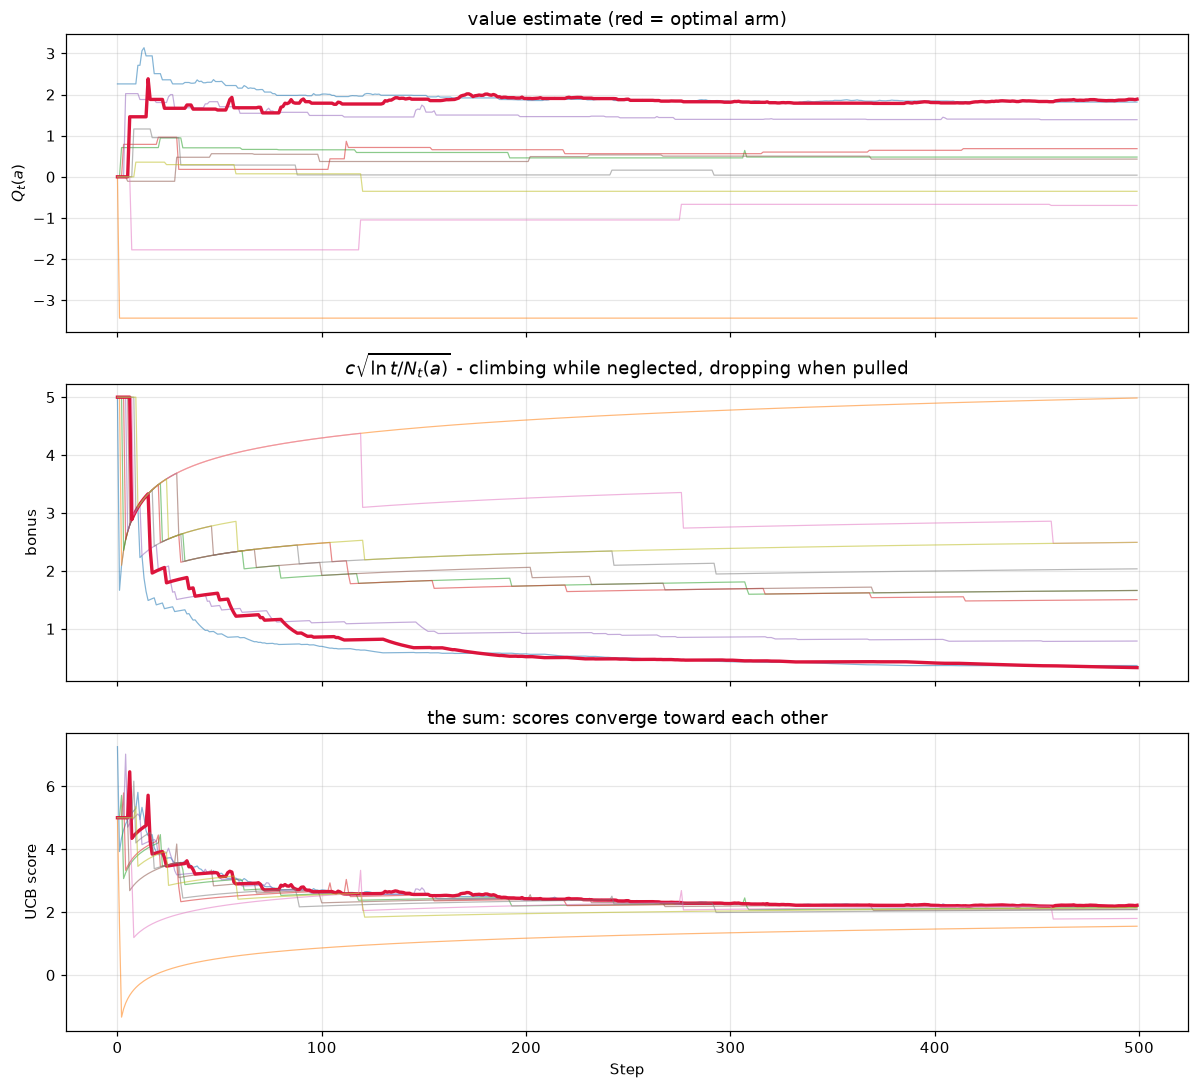

rank  q*      pulls   final bonus
   1    1.83    230   0.329
   2    1.83    186   0.366
   3    1.32     40   0.788
   4    0.96      9   1.662
   5    0.58      4   2.493
   6    0.39      9   1.662
   7    0.07     11   1.503
   8    0.03      4   2.493
   9   -0.52      6   2.035
  10   -3.08      1   4.986


In [6]:
def ucb_diagnostics(c=2.0, steps=500, seed=13):
    rng = np.random.default_rng(seed)
    q = rng.normal(0, 1, size=10)
    Q = np.zeros(10); N = np.zeros(10)
    Qh, Bh, Ah = [], [], []
    for t in range(1, steps + 1):
        with np.errstate(divide="ignore", invalid="ignore"):
            bonus = c * np.sqrt(np.log(t) / N)
        bonus[N == 0] = 1e6
        a = int(np.argmax(Q + bonus))
        r = rng.normal(q[a], 1.0)
        N[a] += 1; Q[a] += (r - Q[a]) / N[a]
        Qh.append(Q.copy()); Bh.append(np.minimum(bonus, 5)); Ah.append(a)
    return q, np.array(Qh), np.array(Bh), np.array(Ah), N

q, Qh, Bh, Ah, N = ucb_diagnostics()
best = q.argmax()

fig, axes = plt.subplots(3, 1, figsize=(11, 10), sharex=True)
for a in range(10):
    st = dict(lw=2.2, color="crimson") if a == best else dict(lw=0.8, alpha=0.55)
    axes[0].plot(Qh[:, a], **st)
    axes[1].plot(Bh[:, a], **st)
    axes[2].plot(Qh[:, a] + Bh[:, a], **st)
axes[0].set_ylabel("$Q_t(a)$"); axes[0].set_title("value estimate (red = optimal arm)")
axes[1].set_ylabel("bonus"); axes[1].set_title(r"$c\sqrt{\ln t / N_t(a)}$ - climbing while neglected, dropping when pulled")
axes[2].set_ylabel("UCB score"); axes[2].set_title("the sum: scores converge toward each other")
axes[2].set_xlabel("Step")
for ax in axes: ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

order = np.argsort(-q)
print("rank  q*      pulls   final bonus")
for a in order:
    print(f"{list(order).index(a)+1:>4}  {q[a]:>6.2f}  {int(N[a]):>5}   {Bh[-1,a]:.3f}")

The bottom panel is the punchline: **all the UCB scores drift toward each other.** A
good arm gets pulled, its bonus falls, its score falls. A neglected arm's bonus climbs
until its score catches up and it gets sampled once — which knocks it back down. UCB
maintains a kind of equilibrium in which the *upper bound* of every arm is roughly
equal, and it spends pulls in inverse proportion to how clearly an arm is beaten.

Check the table: pull count falls off steeply with rank, but nothing is at zero. That is
$O(\log T)$ regret in action — the theory says
$\mathbb{E}[N_T(a)] \approx \frac{8\ln T}{\Delta_a^2}$, i.e. arms that are barely worse
get sampled a lot (cheap mistakes) and arms that are much worse get sampled rarely.

---

### Predict first

UCB looks strictly better than $\varepsilon$-greedy so far. Two questions:

1. What happens if we put UCB on the **nonstationary** testbed from 2.5?
2. UCB is the strongest method in the chapter on the standard testbed, yet Sutton &
   Barto say it "is more difficult than $\varepsilon$-greedy to extend beyond bandits."
   Why might that be?

*Write your guess down (mentally or in the cell below) before running the next cell. The point is not to be right — it is to make the surprise informative when you are wrong.*

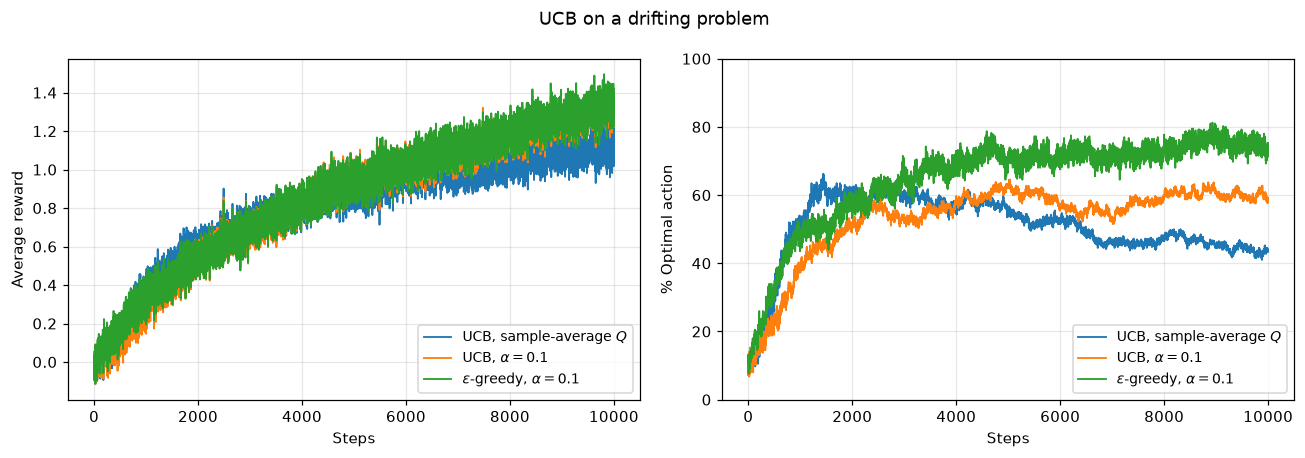

UCB 1/n      %opt last 2000 =  45.7
UCB alpha    %opt last 2000 =  60.4
eps alpha    %opt last 2000 =  75.2


In [7]:
kw = {"drift_sigma": 0.01, "equal_start": True}
T = 10000
u_ns = run_bandit(ucb_agent(2.0), testbed_kwargs=kw, steps=T, runs=400, seed=3)
u_ns_a = run_bandit(ucb_agent(2.0, alpha=0.1), testbed_kwargs=kw, steps=T, runs=400, seed=3)
e_ns = run_bandit(eps_agent(0.1, alpha=0.1), testbed_kwargs=kw, steps=T, runs=400, seed=3)

plot_pair([u_ns, u_ns_a, e_ns],
          ["UCB, sample-average $Q$", "UCB, $\\alpha=0.1$",
           "$\\varepsilon$-greedy, $\\alpha=0.1$"],
          title="UCB on a drifting problem")
plt.show()

for lab, r in [("UCB 1/n", u_ns), ("UCB alpha", u_ns_a), ("eps alpha", e_ns)]:
    print(f"{lab:<12} %opt last 2000 = {r['optimal'][-2000:].mean():5.1f}")

In [8]:
hide('''<b>1.</b> Plain UCB degrades badly. Its bonus depends on N_t(a), which only ever
grows, so its willingness to re-examine an arm decays as 1/&radic;N &mdash; far too slowly
adaptive for a target that keeps moving. Swapping the value update to constant &alpha;
helps the <i>estimates</i> track, but the <i>exploration schedule</i> is still tied to
total counts since t=0. A properly nonstationary UCB needs a discounted or sliding-window
count, which is outside the book&#39;s scope.
<br><br><b>2.</b> Three reasons UCB does not extend easily:
<br>&bull; <b>Nonstationarity</b> &mdash; as above, and full RL is intrinsically
nonstationary because the policy keeps changing.
<br>&bull; <b>Large state spaces</b> &mdash; N_t(a) is a per-(state, action) visit count.
With function approximation you have no such counts, and inventing a surrogate
(&quot;pseudo-counts&quot;) is an active research area.
<br>&bull; <b>The bonus assumes independent estimates</b> &mdash; with generalisation,
learning about one action changes your estimate for others, and &radic;(ln t / N) no longer
describes your uncertainty.
<br><br>&epsilon;-greedy has none of these problems, which is why it is still everywhere
despite being cruder.''')

## Takeaways for 2.7

1. UCB explores by **optimism under uncertainty**: score = estimate + confidence width.
2. $1/\sqrt{N_t(a)}$ is a standard error; $\ln t$ makes neglected arms slowly resurface.
3. The step-11 spike happens because after one pull each, the bonuses are equal and
   cancel, so UCB makes its first *informed* choice; step 12 penalises that arm's now-larger
   $N$ and pushes it away.
4. UCB spends pulls $\propto \ln T/\Delta_a^2$ — it invests exactly where mistakes are
   cheap, giving $O(\log T)$ regret.
5. It does not transfer well to nonstationary or large-state problems.

**Next:** stop estimating values altogether and learn *preferences* directly —
Section 2.8.